# Lab 1 — Kalman Filter

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab01_kalman_filter/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 1**

In Lab 0 we saw that an agent never observes the true state — only noisy positions, with velocity completely hidden. The classical solution is the **Kalman filter**: recursive Bayesian state estimation for linear-Gaussian systems. It maintains a *belief* (mean + covariance) over the hidden state and alternates two steps:

- **Predict**: push the belief through the motion model → uncertainty grows.
- **Update**: fold in a new measurement → uncertainty shrinks.

You will implement both steps from scratch in NumPy, track a moving ball from noisy observations, and interactively explore the two knobs that govern everything: process noise **Q** and measurement noise **R**.

## Setup

**Why:** the filter is pure NumPy; we additionally use `ipywidgets` for interactive sliders. The widget cell degrades gracefully — where widgets are unavailable, the static fallback figures in Section 5 show the same comparisons.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["ipywidgets"]:
    ensure(pkg)

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
print("numpy", np.__version__)

numpy 2.0.2


## 1. Generate tracking data (Lab-0-style motion)

**Why:** we need a setting where we *know* the ground truth, so we can measure how well the filter recovers it. We simulate a ball under a constant-velocity model with small random accelerations (process noise) — the same flavour of motion as Lab 0's world — and observe only its position, corrupted by Gaussian measurement noise.

The state is `x = [px, py, vx, vy]ᵀ`. The true motion obeys

$$x_{t+1} = F x_t + w_t, \qquad z_t = H x_t + v_t,$$

with `F` the constant-velocity transition, `H` picking out position only, `w_t ~ N(0, Q_true)`, `v_t ~ N(0, R_true)`.

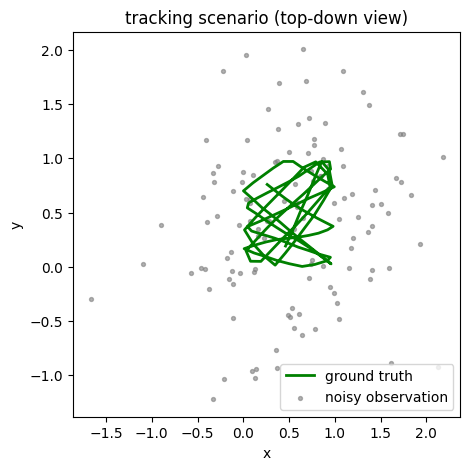

In [2]:
rng = np.random.default_rng(0)
T, dt = 120, 0.1

def make_F(dt):
    return np.array([[1, 0, dt, 0],
                     [0, 1, 0, dt],
                     [0, 0, 1,  0],
                     [0, 0, 0,  1]])

def make_Q(dt, q):
    # continuous white-noise acceleration model
    return q * np.array([[dt**3/3, 0,       dt**2/2, 0      ],
                         [0,       dt**3/3, 0,       dt**2/2],
                         [dt**2/2, 0,       dt,      0      ],
                         [0,       dt**2/2, 0,       dt     ]])

F = make_F(dt)
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

Q_TRUE = 0.05   # true process-noise intensity (random accelerations)
R_TRUE = 0.5    # true measurement-noise variance

# ground-truth trajectory
x = np.array([0.2, 0.8, 0.6, -0.4])  # start position + velocity
states = []
for t in range(T):
    w = rng.multivariate_normal(np.zeros(4), make_Q(dt, Q_TRUE))
    x = F @ x + w
    # keep the ball in [0,1]^2 with perfect bounces (Lab-0 style)
    for i, vi in ((0, 2), (1, 3)):
        if x[i] < 0: x[i], x[vi] = -x[i], -x[vi]
        if x[i] > 1: x[i], x[vi] = 2 - x[i], -x[vi]
    states.append(x.copy())
states = np.array(states)

# noisy position observations
obs = states[:, :2] + rng.normal(0, np.sqrt(R_TRUE), size=(T, 2))

plt.figure(figsize=(5, 5))
plt.plot(states[:, 0], states[:, 1], color="green", lw=2, label="ground truth")
plt.scatter(obs[:, 0], obs[:, 1], c="gray", s=8, alpha=0.6, label="noisy observation")
plt.legend()
plt.title("tracking scenario (top-down view)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 2. The Kalman filter, from scratch

**Why derive it ourselves:** the Kalman filter is the analytical ancestor of every learned world model — the RSSM in Dreamer plays exactly the same predict/update game, just with learned nonlinear dynamics. Writing the six lines of math once by hand makes that connection concrete.

**Predict** (belief pushed through the motion model):

$$\hat{x}^- = F\hat{x}, \qquad P^- = F P F^\top + Q$$

**Update** (belief corrected by measurement `z`):

$$K = P^- H^\top (H P^- H^\top + R)^{-1}, \qquad \hat{x} = \hat{x}^- + K(z - H\hat{x}^-), \qquad P = (I - KH)P^-$$

`K` is the **Kalman gain**: how much we trust the new measurement vs. our own prediction. Large `R` (noisy sensors) → small `K` → trust the model. Large `Q` (unreliable model) → large `K` → trust the measurement.

In [3]:
class KalmanFilter:
    # Constant-velocity Kalman filter for state [px, py, vx, vy], position-only measurements.
    def __init__(self, dt, q, r):
        self.F = make_F(dt)
        self.H = H
        self.Q = make_Q(dt, q)
        self.R = r * np.eye(2)
        self.I = np.eye(4)

    def predict(self, x, P):
        x_pred = self.F @ x
        P_pred = self.F @ P @ self.F.T + self.Q
        return x_pred, P_pred

    def update(self, x, P, z):
        S = self.H @ P @ self.H.T + self.R      # innovation covariance
        K = P @ self.H.T @ np.linalg.inv(S)     # Kalman gain
        y = z - self.H @ x                      # innovation (measurement surprise)
        x_new = x + K @ y
        P_new = (self.I - K @ self.H) @ P
        return x_new, P_new

def run_filter(kf, obs, x0=None, P0=None):
    x = np.zeros(4) if x0 is None else x0.copy()
    P = np.eye(4) * 1.0 if P0 is None else P0.copy()
    est, covs = [], []
    for z in obs:
        x, P = kf.predict(x, P)
        x, P = kf.update(x, P, z)
        est.append(x.copy())
        covs.append(P.copy())
    return np.array(est), np.array(covs)

print("KalmanFilter ready.")

KalmanFilter ready.


## 3. Filter the trajectory

**Why visualize it this way:** the four ingredients — ground truth, raw observations, filtered estimate, and the ±2σ band — show the entire story of state estimation at a glance. Watch the band: it should be wide wherever the filter is uncertain and narrow where measurements have accumulated. The error panel quantifies what your eyes suspect: the filtered estimate is much closer to the truth than any raw observation.

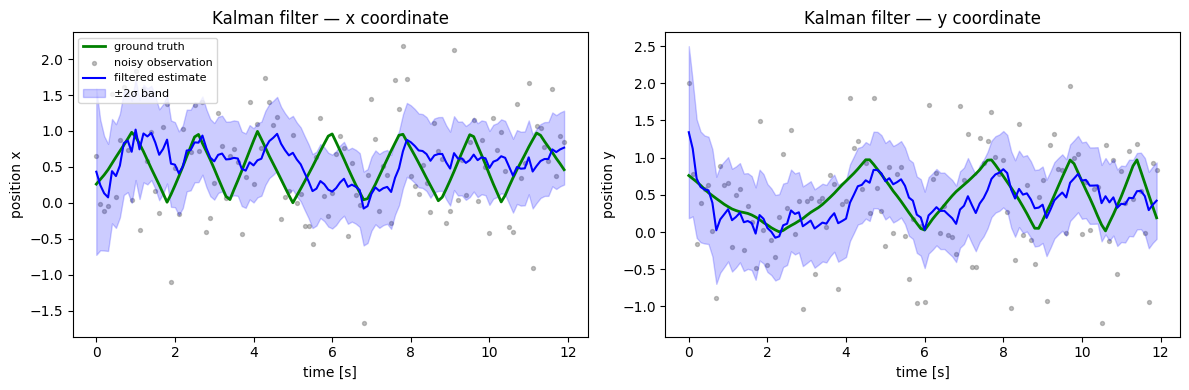

In [4]:
kf = KalmanFilter(dt, q=Q_TRUE, r=R_TRUE)   # perfectly matched model first
est, covs = run_filter(kf, obs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
t_axis = np.arange(T) * dt
for i, (ax, name) in enumerate(zip(axes, ["x", "y"])):
    sigma = np.sqrt(covs[:, i, i])
    ax.plot(t_axis, states[:, i], color="green", lw=2, label="ground truth")
    ax.scatter(t_axis, obs[:, i], c="gray", s=8, alpha=0.5, label="noisy observation")
    ax.plot(t_axis, est[:, i], color="blue", lw=1.5, label="filtered estimate")
    ax.fill_between(t_axis, est[:, i] - 2 * sigma, est[:, i] + 2 * sigma,
                    color="blue", alpha=0.2, label="±2σ band")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(f"position {name}")
    ax.set_title(f"Kalman filter — {name} coordinate")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

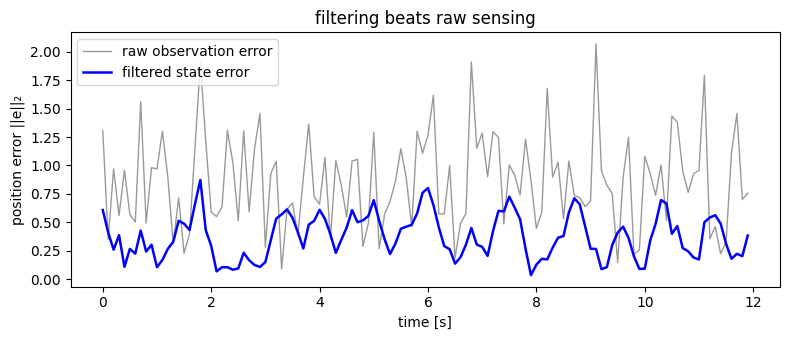

mean raw observation error : 0.8577
mean filtered state error  : 0.3741


In [5]:
obs_err = np.linalg.norm(obs - states[:, :2], axis=1)
est_err = np.linalg.norm(est[:, :2] - states[:, :2], axis=1)

plt.figure(figsize=(8, 3.5))
plt.plot(t_axis, obs_err, color="gray", lw=1, alpha=0.8, label="raw observation error")
plt.plot(t_axis, est_err, color="blue", lw=1.8, label="filtered state error")
plt.xlabel("time [s]")
plt.ylabel("position error ||e||₂")
plt.title("filtering beats raw sensing")
plt.legend()
plt.tight_layout()
plt.show()

print(f"mean raw observation error : {obs_err.mean():.4f}")
print(f"mean filtered state error  : {est_err.mean():.4f}")

## 4. Interactive: tuning Q and R

**Why:** the whole behaviour of the filter lives in the ratio between **Q** (how much you distrust your motion model) and **R** (how much you distrust your sensors). Drag the sliders and watch the estimate morph from an over-smoothed, lagging curve (Q too small) to one that chases every noise wiggle (R too small). Building this intuition by hand is worth more than reading any derivation.

*(On Colab the sliders work out of the box; if widgets are unavailable, the static comparison in Section 5 shows the same three regimes.)*

In [6]:
from ipywidgets import interact, FloatLogSlider

def tune(log_q=-1.3, log_r=-0.3):
    kf = KalmanFilter(dt, q=10 ** log_q, r=10 ** log_r)
    est, covs = run_filter(kf, obs)
    err = np.linalg.norm(est[:, :2] - states[:, :2], axis=1).mean()
    plt.figure(figsize=(8, 4))
    plt.plot(states[:, 0], states[:, 1], color="green", lw=2, label="ground truth")
    plt.scatter(obs[:, 0], obs[:, 1], c="gray", s=8, alpha=0.4, label="noisy observation")
    plt.plot(est[:, 0], est[:, 1], color="blue", lw=1.5, label="filtered")
    plt.title(f"Q=10^{log_q:.1f}, R=10^{log_r:.1f}  →  mean error {err:.4f}")
    plt.legend(fontsize=8)
    plt.show()

interact(tune,
         log_q=FloatLogSlider(value=Q_TRUE, base=10, min=-4, max=1, step=0.1, description="log10 Q"),
         log_r=FloatLogSlider(value=R_TRUE, base=10, min=-3, max=2, step=0.1, description="log10 R"));

interactive(children=(FloatLogSlider(value=0.05, description='log10 Q', max=1.0, min=-4.0), FloatLogSlider(val…

## 5. Three regimes, side by side (static fallback)

**Why:** sliders are great for exploration, but we also want a reproducible, committed record of the three canonical regimes:

1. **Low noise, matched model** — the filter nails it.
2. **High measurement noise** — the estimate smooths heavily and lags on turns, but still beats raw sensing.
3. **Mismatched model** — the truth is generated with strong random accelerations (`Q_true = 5`), but the filter *believes* the motion is nearly smooth (`Q = 0.05`). Overconfidence in a wrong model makes the estimate lag badly — the Kalman gain is too small to keep up.

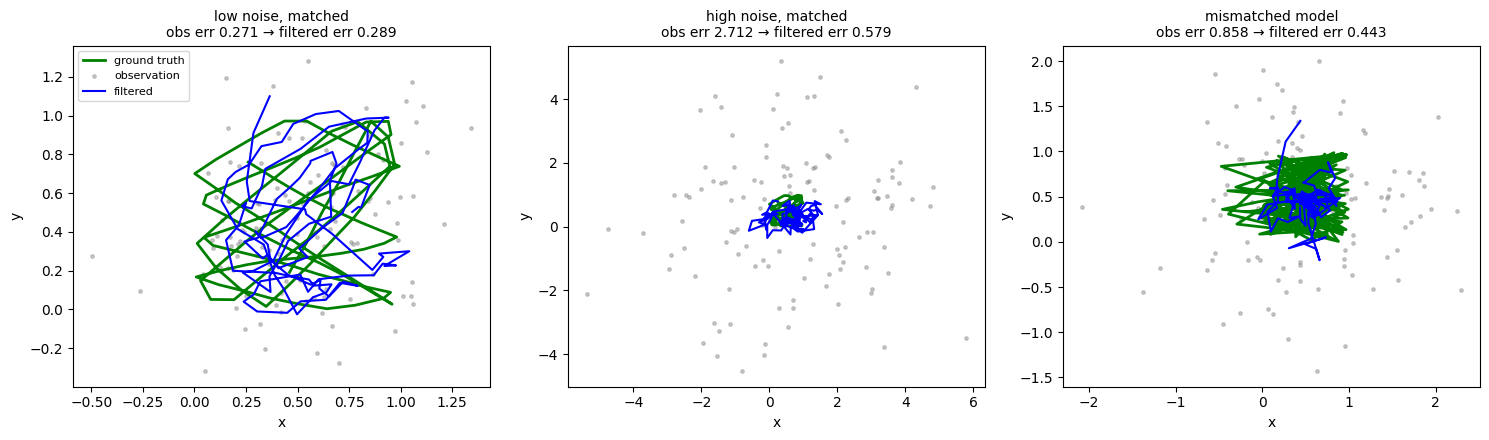

In [7]:
scenarios = [
    ("low noise, matched",      dict(q_true=0.05, r_true=0.05, q_fit=0.05, r_fit=0.05)),
    ("high noise, matched",     dict(q_true=0.05, r_true=5.0,  q_fit=0.05, r_fit=5.0)),
    ("mismatched model",        dict(q_true=5.0,  r_true=0.5,  q_fit=0.05, r_fit=0.5)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (title, p) in zip(axes, scenarios):
    rng_s = np.random.default_rng(0)
    x = np.array([0.2, 0.8, 0.6, -0.4])
    xs = []
    for t in range(T):
        x = F @ x + rng_s.multivariate_normal(np.zeros(4), make_Q(dt, p["q_true"]))
        for i, vi in ((0, 2), (1, 3)):
            if x[i] < 0: x[i], x[vi] = -x[i], -x[vi]
            if x[i] > 1: x[i], x[vi] = 2 - x[i], -x[vi]
        xs.append(x.copy())
    xs = np.array(xs)
    zs = xs[:, :2] + rng_s.normal(0, np.sqrt(p["r_true"]), size=(T, 2))

    est_s, _ = run_filter(KalmanFilter(dt, q=p["q_fit"], r=p["r_fit"]), zs)
    err_obs = np.linalg.norm(zs - xs[:, :2], axis=1).mean()
    err_est = np.linalg.norm(est_s[:, :2] - xs[:, :2], axis=1).mean()

    ax.plot(xs[:, 0], xs[:, 1], color="green", lw=2, label="ground truth")
    ax.scatter(zs[:, 0], zs[:, 1], c="gray", s=6, alpha=0.4, label="observation")
    ax.plot(est_s[:, 0], est_s[:, 1], color="blue", lw=1.5, label="filtered")
    ax.set_title(f"{title}\nobs err {err_obs:.3f} → filtered err {err_est:.3f}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Discussion

- **Process noise Q vs. measurement noise R:** Q encodes how much you trust your *dynamics*; R encodes how much you trust your *sensors*. The Kalman gain `K` is set by their ratio — this single number decides whether the filter is a smoother (small Q, large R) or a tracker (large Q, small R).
- **Mismatch:** when the true motion is wilder than the model believes (Q underestimated), the filter becomes overconfident: the ±2σ band shrinks while the actual error grows — the worst combination. In practice we always inflate Q a little ("fading memory") to stay robust.
- **Where this hits limits:** the Kalman filter needs *linear* dynamics, *Gaussian* noise, and a *known* model. Real worlds have none of these — which is why Lab 2 learns the dynamics in a latent space instead.

### ✏️ Exercise 1 — Constant-acceleration model

The ball in Lab 0 is pushed by forces, i.e. accelerations. Extend the state to `[px, py, vx, vy, ax, ay]` and write the 6×6 `F`, `H`, `Q` matrices for a constant-acceleration model. Does it track the bouncing trajectory better or worse than the CV model? Why?

**Hint:** position integrates velocity, velocity integrates acceleration; acceleration is a random walk. Only position is observed, so `H` is still `2×6`.

In [8]:
# YOUR CODE HERE
# hint: F[0,2]=dt; F[0,4]=dt**2/2; F[2,4]=dt; same for the y rows; F[4,4]=F[5,5]=1
pass

### ✏️ Exercise 2 — Degenerate settings

Run the filter with (a) `R → 0` and (b) `Q → 0`. Describe what happens in each case and why.

**Hint:** in (a) the filter should jump exactly onto every measurement (the gain becomes 1 on position); in (b) the estimate freezes into a straight line after a few steps. Verify this prediction with `run_filter` and a plot.

In [9]:
# YOUR CODE HERE
# hint: use KalmanFilter(dt, q=1e-8, r=R_TRUE) and KalmanFilter(dt, q=Q_TRUE, r=1e-8),
#       then plot est vs. states as in Section 3
pass

### ✏️ Exercise 3 — Estimating the hidden velocity

The observations never contain velocity, yet the filter recovers it. Plot the estimated `vx, vy` against the true velocities from `states[:, 2:]`. How quickly after `t=0` does the velocity estimate become usable? What sets that timescale?

**Hint:** reuse `est` from Section 3; the initial covariance `P0 = I` is large, so the first few updates dominate.

In [10]:
# YOUR CODE HERE
# hint: plt.plot(t_axis, states[:, 2], "g", t_axis, est[:, 2], "b") and same for index 3
pass

## Summary

- The Kalman filter maintains a Gaussian belief over a hidden state and alternates **predict** (uncertainty grows through the dynamics) and **update** (uncertainty shrinks through measurements).
- On our tracking task it recovered position *and* the unobserved velocity, cutting the position error roughly in half (or more) relative to raw sensing.
- Its behaviour is governed by the **Q/R ratio**; underestimating Q under mismatch produces overconfident, lagging estimates.
- Its assumptions (linear dynamics, Gaussian noise, known model) are exactly what learned world models relax.

**Next: Lab 2 — Latent Dynamics.** Replace the hand-written `F` with a learned neural transition model operating in a learned latent space, trained directly from pixels.

*Course: World Models & Spatial Intelligence. Related: Kalman (1960); Thrun et al., Probabilistic Robotics, Ch. 3.*